### Compare gebco data

#### 1. Packages

In [1]:
# Packages
import matplotlib.pyplot as plt
import rioxarray as rxr
import xarray as xr

#### 2. Load data

In [2]:
# URLs to gebco data (Lowest astronomical tide, Highest astronomical tide and Depth)
url_hat_lat_RW = r'https://storage.googleapis.com/cmems-sdb/gebco/gebco_2023_hat_lat.tif'
url_hat_lat_MV = r'https://nx7384.your-storageshare.de/apps/sharingpath/wetwin/public/gebco2023'

In [3]:
# Load gebco data RW
da_gebco_RW = rxr.open_rasterio(url_hat_lat_RW)
da_gebco_RW.coords['band'] = ['HAT', 'LAT']

# Load in situ data MV
da_lat_MV  = xr.open_zarr(url_hat_lat_MV + '/lat.zarr')['lat_correction']
da_hat_MV  = xr.open_zarr(url_hat_lat_MV + '/hat.zarr')['hat_correction']
da_depth_MV  = xr.open_zarr(url_hat_lat_MV + '/depth_msl.zarr')['depth_msl']
da_gebco_MV = xr.concat([da_hat_MV, da_lat_MV, da_depth_MV], dim='band')
da_gebco_MV = da_gebco_MV.rename({'lon':'x', 'lat':'y'})
da_gebco_MV = da_gebco_MV.reindex(y=list(reversed(da_gebco_MV.y)))
da_gebco_MV.coords['band'] = ['HAT', 'LAT', 'Depth MSL']
da_gebco_MV = da_gebco_MV.rio.write_crs(da_gebco_RW.rio.crs)

#### 3. Compare in gebco data (RW and MV)

In [4]:
# Plot settings
lon_min = 0.0 #western border
lon_max = 10.0 #eastern border
lat_min = 50.0 #southern border
lat_max = 60.0 #northern border 
plot_skip = 10 # 1= at full resolution

# Subset data
da_gebco_RW_ss = da_gebco_RW.sel(x=slice(lon_min, lon_max, plot_skip), y=slice(lat_min, lat_max, -plot_skip))
da_gebco_MV_ss = da_gebco_MV.sel(x=slice(lon_min, lon_max, plot_skip), y=slice(lat_min, lat_max, -plot_skip)).sel(band=['HAT', 'LAT'])
da_gebco_diff_ss = da_gebco_RW_ss.copy(deep=True)
da_gebco_diff_ss.values = da_gebco_RW_ss.values - da_gebco_MV_ss.values

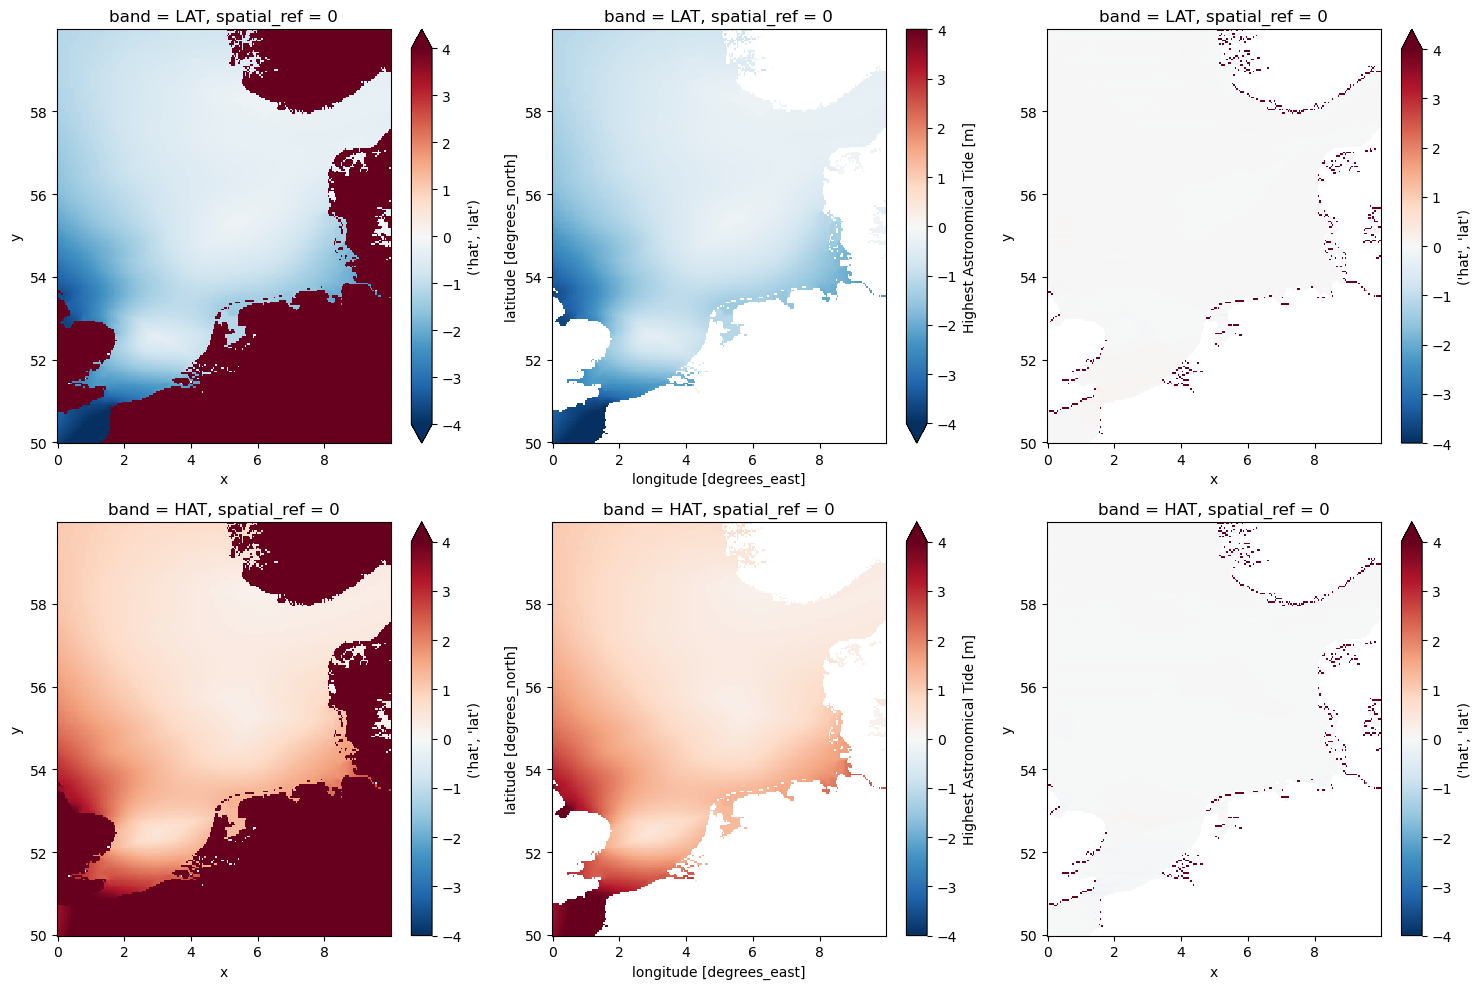

In [5]:
# Plot data
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.ravel()
da_gebco_RW_ss.sel(band='LAT').plot(ax=axs[0], cmap='RdBu_r', vmin=-4, vmax=4)
da_gebco_MV_ss.sel(band='LAT').plot(ax=axs[1], cmap='RdBu_r', vmin=-4, vmax=4)
da_gebco_diff_ss.sel(band='LAT').plot(ax=axs[2], cmap='RdBu_r', vmin=-4, vmax=4)
da_gebco_RW_ss.sel(band='HAT').plot(ax=axs[3], cmap='RdBu_r', vmin=-4, vmax=4)
da_gebco_MV_ss.sel(band='HAT').plot(ax=axs[4], cmap='RdBu_r', vmin=-4, vmax=4)
da_gebco_diff_ss.sel(band='HAT').plot(ax=axs[5], cmap='RdBu_r', vmin=-4, vmax=4)
fig.tight_layout()
plt.show()